<a href="https://colab.research.google.com/github/MehdiSaraeian/Classification/blob/add-workshop-scenarios/scenarios/04-xgboost/Scenario_4_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 4: Peak Performance: Competitive Classification with Gradient Boosting

Time for the heavy hitters! In this scenario, we'll use XGBoost (Extreme Gradient Boosting), a library famous for its performance in machine learning competitions. We will also learn about a more robust evaluation metric: ROC AUC.

## 1. Import Libraries and Prepare Data

Let's get our environment ready. We'll need to import the `xgboost` library. If you don't have it, run `pip install xgboost` in your terminal or a new cell.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt

# --- Data Prep ---
column_names = [
    'id', 'clump_thickness', 'unif_cell_size', 'unif_cell_shape',
    'marg_adhesion', 'single_epith_cell_size', 'bare_nuclei',
    'bland_chrom', 'norm_nucleoli', 'mitoses', 'class'
]
df = pd.read_csv('/content/breast-cancer-wisconsin.data', names=column_names)
df['bare_nuclei'] = df['bare_nuclei'].replace('?', np.nan)
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'])
df['bare_nuclei'] = df['bare_nuclei'].fillna(df['bare_nuclei'].median())
df.drop('id', axis=1, inplace=True)
df['class'] = df['class'].map({2: 0, 4: 1})
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 2. Train the XGBoost Classifier

Let's initialize and train our XGBoost model. We'll set a few common hyperparameters to get started.

In [2]:
# HINT: Create an instance of xgb.XGBClassifier.
# Important parameters: objective='binary:logistic', use_label_encoder=False, eval_metric='logloss'.
# Then, .fit() it to the training data.

# YOUR CODE HERE
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [18:43:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## 3. Make Predictions and Evaluate

To calculate the ROC AUC score, we need the predicted probabilities for the positive class, not just the final class predictions.

In [3]:
# HINT: Use .predict() for the classification report and .predict_proba() for the AUC score.
# .predict_proba() returns probabilities for both classes, so you'll want to select the second column `[:, 1]`.

# YOUR CODE HERE
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("--- XGBoost Classifier ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate ROC AUC Score
auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc:.4f}")

--- XGBoost Classifier ---

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        92
           1       0.94      0.96      0.95        48

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140

ROC AUC Score: 0.9917


## 4. Plot the ROC Curve

A visual representation of our model's performance! A perfect model would have a curve that goes straight up the y-axis and across the top.

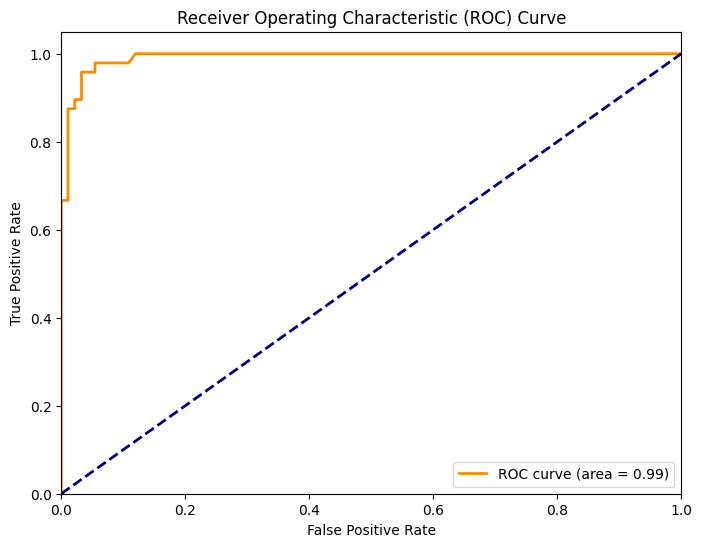

In [4]:
# HINT: Use the roc_curve() function to get the false positive rates (fpr) and true positive rates (tpr).
# Then, plot fpr vs. tpr using matplotlib.

# YOUR CODE HERE
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

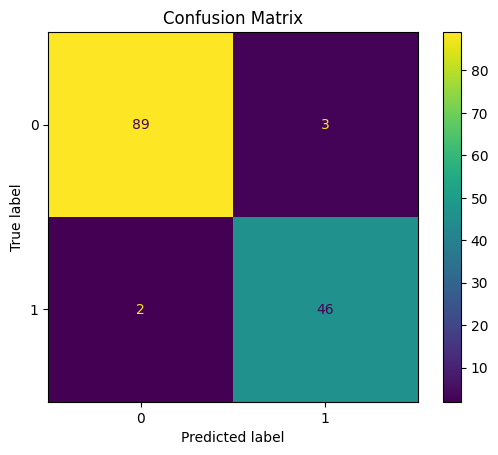

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) # Assuming 0 and 1 are your class labels

disp.plot()
plt.title('Confusion Matrix')
plt.show()

<Figure size 1000x600 with 0 Axes>

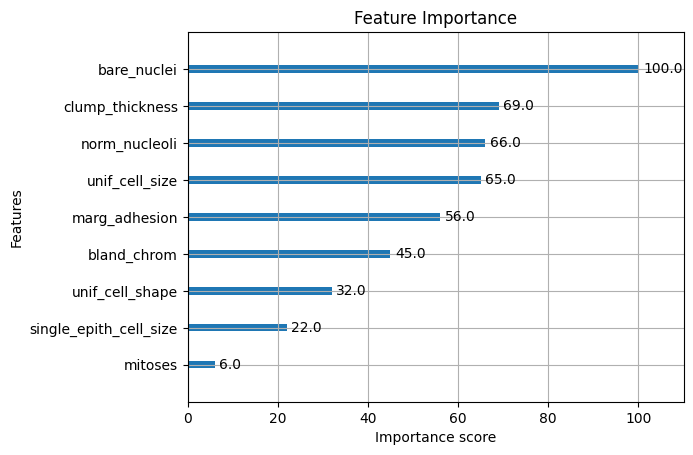

In [6]:
# Plotting Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='weight') # You can also use 'gain' or 'cover'
plt.title('Feature Importance')
plt.show()